### EDA, Exploratory Data Analysis
##### Dataset1: chest x-rays, dicom data converted to jpgs and csv

In [3]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches      # rectangles for bounding boxes
from PIL import Image                      # read JPGs (and their dimensions)

In [4]:
# Unzip dataset
import zipfile
from zipfile import ZipFile
from pathlib import Path

DATA_DIR = Path("/Users/emilyahmad/Desktop/projects/Pneumonia-Detection/Data/dataset_1.zip")

assert DATA_DIR.exists(), f"dataset not found at {DATA_DIR}."

# Unzip dataset_1.zip

with ZipFile(DATA_DIR, "r") as zObject:
    zObject.extractall(path="/Users/emilyahmad/Desktop/projects/Pneumonia-Detection/Data")

# Change path to dataset_1 folder instead of zip
DATA_DIR = DATA_DIR.with_suffix("")

TRAIN_IMG_DIR = DATA_DIR / "train_images"
train_labels = pd.read_csv(DATA_DIR / "train_labels.csv")

VAL_IMG_DIR   = DATA_DIR / "val_images"
TEST_IMG_DIR  = DATA_DIR / "test_images"

# Random generator starts at reproducible starting point (returns same sample of rows)
SAMPLE_SEED = 42

##### train_labels.csv
##### Table of patient data
##### Patient ID, boundary box coords, class, patient age and sex, scan view, body part, data modality and target
##### CR modality: computed radiography (opposed to digital radiography, DR) a different method of taking x-rays
##### Target is the binary class 0 for no pneumonia
##### 3 classes: normal, lung opacity (1), no lung opacity/not normal (0 but abnormal)

___

##### Positive patients have multiple rows (multiple instances of pneumonia detected and multiple boundary boxes)
##### Negative patients have empty cells for boundary box coords
___
##### *Testing split has no labels (ships with submission)

In [5]:
def count_jpgs(d):
    """Count real .jpg files in a folder (ignoring macOS '._' junk)."""
    return sum(1 for f in os.listdir(d) if f.endswith(".jpg") and not f.startswith("._"))
    
    # Because all files are the same (all jpgs) could just check how many files total
    # file_count = sum(1 for item in TRAIN_IMG_DIR.iterdir() if item.is_file())
    # print(f"Total files: {file_count}")

# What folders exist & how many images per
# Counts jpgs in each split using paths defined in Cell 3
print("Split folders (one X-ray per file, named by patientId):")
for name, d in [("Training", TRAIN_IMG_DIR), ("Validation", VAL_IMG_DIR), ("Testing", TEST_IMG_DIR)]:
    
    # :23s and :1d format
    print(f"  {name:23s}: {count_jpgs(d):1d} images")

# Which tables we're given
print("\nLabel tables:")
for name, f in [("Training", "train_labels.csv"), ("Validation", "val_labels.csv"), ("Sample submission", "sample_submission.csv")]:
    p = DATA_DIR / f
    if p.exists():
        # Number of lines in a file (excludes header)
        n = sum(1 for _ in open(p)) - 1
        print(f"  {name:23s}: {n} rows")

Split folders (one X-ray per file, named by patientId):
  Training               : 3000 images
  Validation             : 1500 images
  Testing                : 1500 images

Label tables:
  Training               : 3456 rows
  Validation             : 1723 rows
  Sample submission      : 1500 rows


In [6]:
# Patient with multiple boxes

# value_counts gives frequency of col for each patient (series indexed by id)
multi = train_labels["patientId"].value_counts()

# multi > 1 creates boolean series
# multi[mask] index alignment & removes false rows
multi_pid = multi[multi > 1]

# Shape is a tuple, index or use len() for count value
print(f" {multi_pid.shape[0]} patients have multiple boxes")

# Grabs first patientId with multiple boxes
multi_pid = multi[multi > 1].index[0]

# Filters by patientId
print(f" Patient {multi_pid} has {train_labels[train_labels["patientId"] == multi_pid].shape[0]} boxes:")

# train_labels[train_labels["patientId"] == multi_pid]

# Reduce to 1 row per patient
per_patient = train_labels.drop_duplicates("patientId")
print(f" {len(per_patient)} unqiue rows")

 442 patients have multiple boxes
 Patient 0e03c2d7-9cea-4dc7-8e91-794a8b3ff58d has 4 boxes:
 3000 unqiue rows


In [7]:
# crosstab() gives frequency of target by class, merges 2 non-pneumonia classes
pd.crosstab(per_patient["class"], per_patient["Target"])

Target,0,1
class,,
Lung Opacity,0,750
No Lung Opacity / Not Normal,1259,0
Normal,991,0


In [ ]:
pids = per_patient[per_patient["class"] == "Lung Opacity"]["patientId"].sample(6).tolist()
# 2 rows, 3 cols, 13" x 9"
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, pid in zip(axes.ravel(), pids):
    show_patient(pid, ax)
plt.tight_layout(); plt.show()

NameError: name 'ax' is not defined

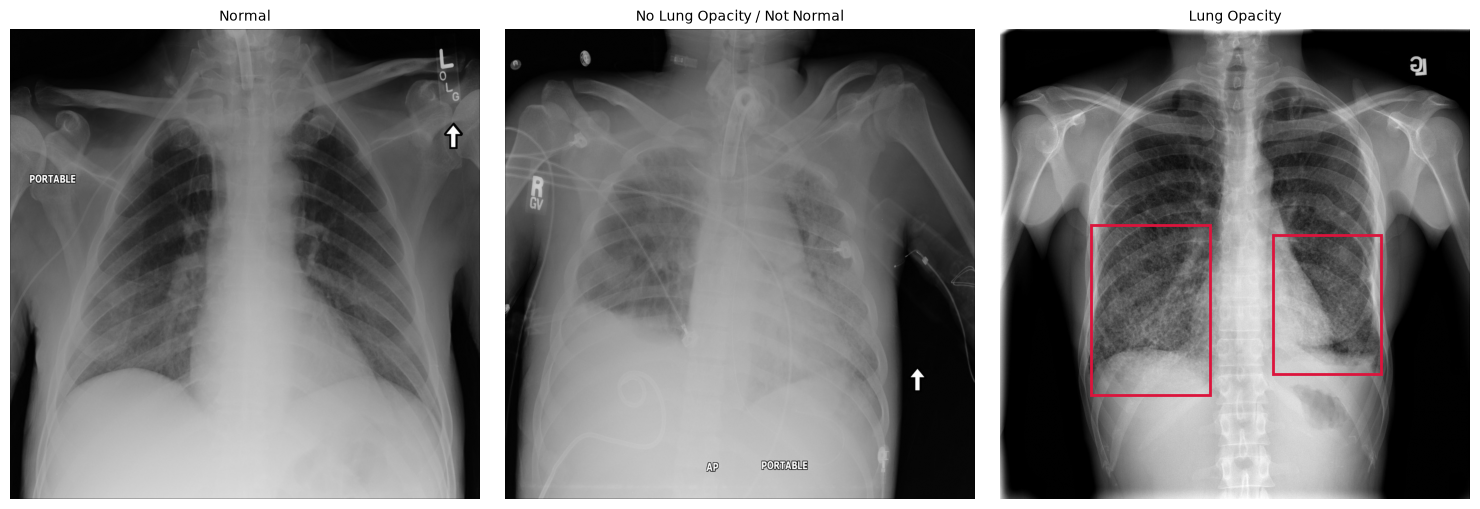

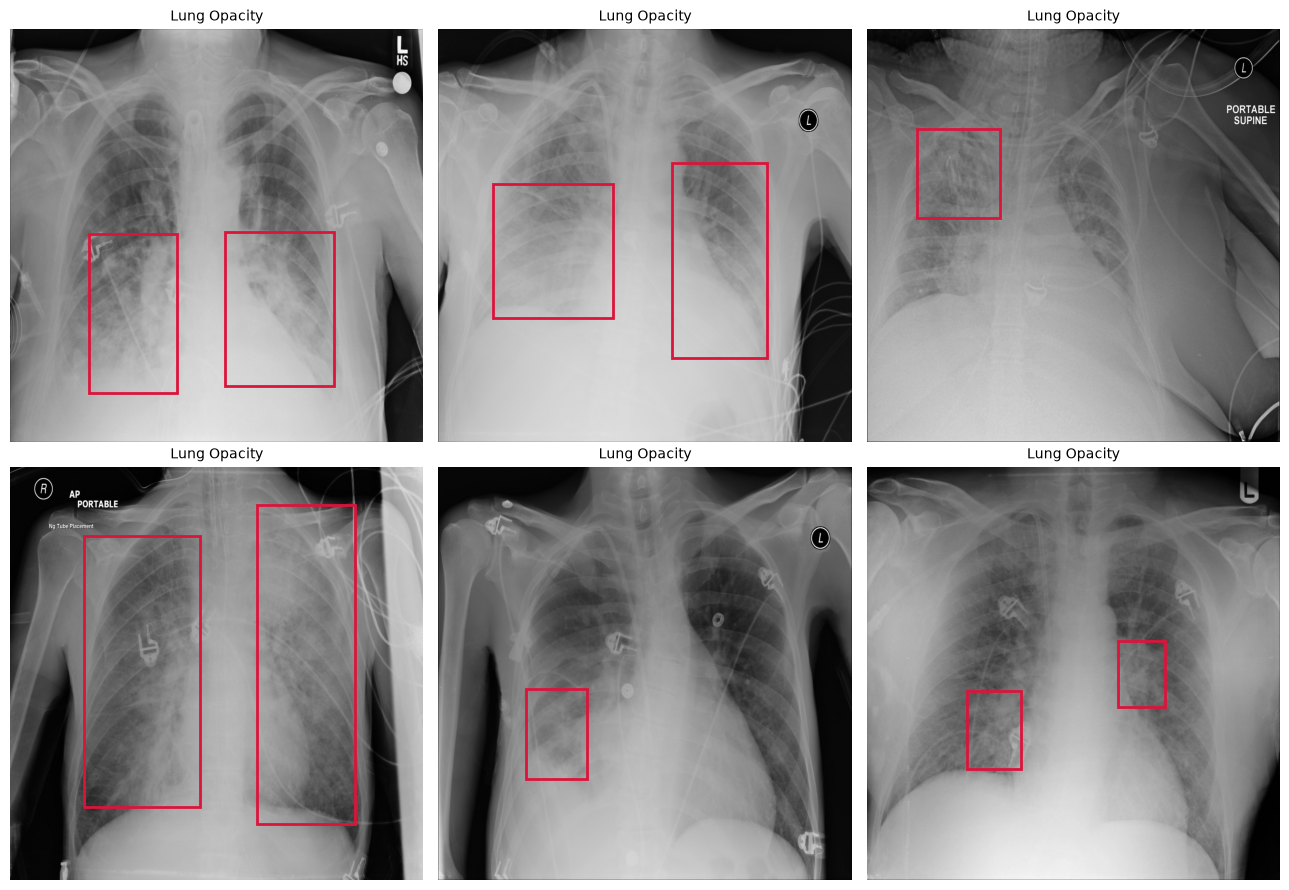

In [ ]:
def boxes_for(patient_id):
    """Bounding boxes for a pneumonia patient as a list of (x, y, w, h); otherwise empty"""
    # Just patient's data
    rows = train_labels[train_labels["patientId"] == patient_id]
    return [(r["x"], r["y"], r["width"], r["height"])
            # iterrows() iterates by row, returns tuple of index & row data
            # (0, Series({"x": 10, "y": 20, "width": 50, "height": 60}))
            # _ = row index, r captures 2nd item
            # notna checks for missing value at x (filters negative patients)
            for _, r in rows.iterrows() if pd.notna(r["x"])]

# fig (overall (window), ax (actual plotting area)
# axes is an array [ax0, ax1, ax2]
def show_patient(patient_id, ax):
    """Draws bounding box rectangles"""
    
    # load_image() loads image & returns as np array of pixexl values
    # ax.imshow() displays array as an image on ax subplot
    # Xrays are grayscale, cmap renders it gray
    ax.imshow(load_image(patient_id), cmap="gray")

    # Unpacks bounding box tuple
    for (x, y, w, h) in boxes_for(patient_id):

        # ax.add_patch() adds rectangle to subplot
        # patches defines rect
        ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="crimson", facecolor="none"))
    
    # Mask & .loc extracts class from true row (matching patientId)
    # iloc gets first item in series & unwraps into plain value
    # cls = patient's string class label
    cls = per_patient.loc[per_patient["patientId"] == patient_id, "class"].iloc[0]
    ax.set_title(cls, fontsize=10)

    # Hides axis ticks, numbers & border lines around subplot
    ax.axis("off")

# None default value set to TRAIN_IMG_DIR
def load_image(patient_id, img_dir=None):
    """Load one X-ray JPG as a grayscale array."""
    img_dir = img_dir or TRAIN_IMG_DIR

    # img_dir converted to Path object
    # PIL image.open() returns image object, converts to Luminance (grayscale)
    # np.array() converts to intensity numbers 2D grid
    return np.array(Image.open(Path(img_dir) / f"{patient_id}.jpg").convert("L"))

order = ["Normal", "No Lung Opacity / Not Normal", "Lung Opacity"]
# 1 row, 3 cols of subplots, figsize 15 in wide, 5 in tall
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Each iteration gets a subplot (ax) and class label
# zip() paris axes & order positionally
for ax, cls in zip(axes, order):
    # Boolean mask of class matches
    pid = per_patient["class"] == cls
    # Filters to patients in that class
    pid = per_patient[pid]
    # Pulls patientId column
    pid = pid["patientId"]
    # Randomly selects 1 row (replace None with 42/fixed seed for same patient each time cell ran)
    pid = pid.sample(1, random_state=None).iloc[0]

    pid = per_patient[per_patient["class"] == cls]["patientId"].sample(1, random_state=None).iloc[0]
    show_patient(pid, ax)

# Adjusts spacing/no overlap/cut off at figure edges
plt.tight_layout()

# Renders
plt.show()

pids = per_patient[per_patient["class"] == "Lung Opacity"]["patientId"].sample(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, pid in zip(axes.ravel(), pids):
    show_patient(pid, ax)
plt.tight_layout(); plt.show()